# Priprema podataka:

In [1]:
import os
os.chdir('/home/lenovo/ip2/archive/csv')
print("Radni direktorijum:", os.getcwd())

Radni direktorijum: /home/lenovo/ip2/archive/csv


**Import biblioteka:**

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [3]:
combine     = pd.read_csv('draft_combine_stats.csv')
player_info = pd.read_csv('common_player_info.csv')


#spajamo podatke
df = combine.merge(
    player_info[['person_id', 'position']],
    left_on='player_id', right_on='person_id', how='left'
)

#biramo atribute za klasterovanje
features = [
    'height_wo_shoes', 'weight', 'wingspan', 'standing_reach',
    'body_fat_pct', 'standing_vertical_leap', 'max_vertical_leap',
    'lane_agility_time', 'three_quarter_sprint'
]

#rad sa nedostajucim podacima
# zadrži red samo ako ima popunjeno najmanje 7 od 9 atributa
#preostale NaN vrednosti (0, 1 ili 2 po igraču) popunjavamo medijanom te kolone
#medijana je bolja od proseka jer nije osetljiva na ekstremne vrednosti

df_clean = df.dropna(subset=features, thresh=len(features)-2).copy()
for col in features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean = df_clean.reset_index(drop=True)

print(f"Broj igrača: {len(df_clean)}")
df_clean[features].describe()
df_clean.to_csv('df_clean.csv', index=False)
df_clean.columns
df_clean.select_dtypes(include='number').columns


Broj igrača: 1016


Index(['season', 'player_id', 'height_wo_shoes', 'height_w_shoes', 'weight',
       'wingspan', 'standing_reach', 'body_fat_pct', 'hand_length',
       'hand_width', 'standing_vertical_leap', 'max_vertical_leap',
       'lane_agility_time', 'modified_lane_agility_time',
       'three_quarter_sprint', 'bench_press', 'person_id'],
      dtype='str')

In [4]:
# Standardizacija podataka

# Ovo je važno za PCA jer PCA zavisi od skale podataka.
X_scaled = StandardScaler().fit_transform(df_clean[features])

# Kreiranje PCA objekta
pca = PCA()

# Primena PCA nad standardizovanim podacima.
# Dobija se nova matrica u kojoj su podaci predstavljeni preko glavnih komponenti.
X_pca = pca.fit_transform(X_scaled)

# Ispis procenta ukupne varijanse koji objašnjavaju prve dve glavne komponente.
# Što je ovaj procenat veći, to prve dve komponente bolje predstavljaju originalne podatke.
print(f"Objašnjena varijansa PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

# Čuvanje imena igrača u poseban niz radi kasnijeg označavanja
# ili prikaza rezultata na grafiku.
player_names = df_clean['player_name'].values

Objašnjena varijansa PC1+PC2: 72.8%


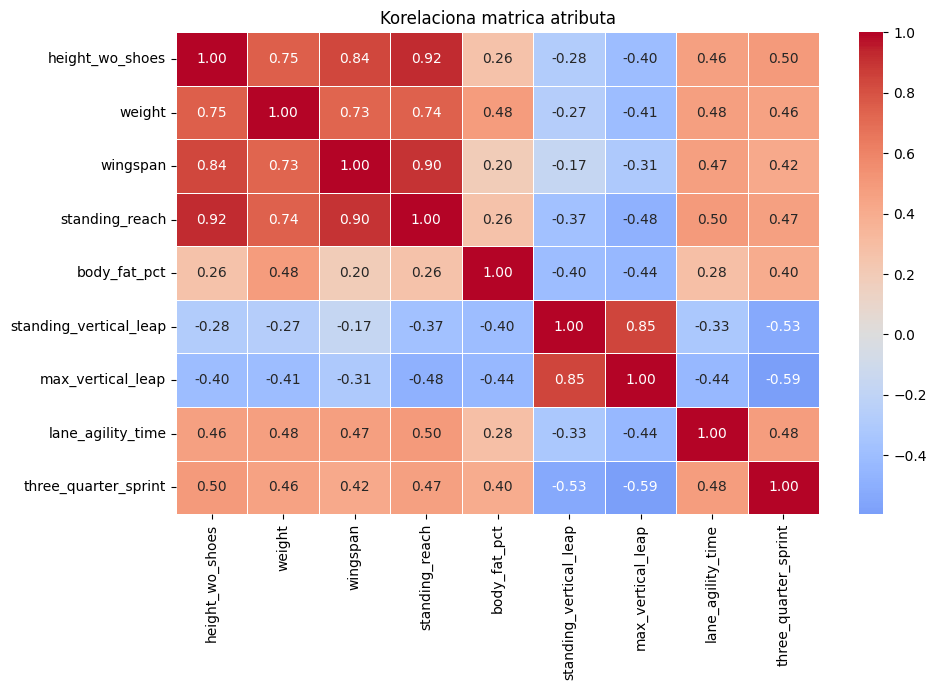

In [5]:
# Kreiranje figure dimenzija 10x7 inča
plt.figure(figsize=(10, 7))

# Iscrtavanje korelacione matrice numeričkih atributa.
# corr() računa Pirsonov koeficijent korelacije između svih parova atributa.
# annot=True ispisuje vrednost korelacije u svakoj ćeliji,
# fmt='.2f' prikazuje vrednosti sa dve decimale,
# cmap='coolwarm' koristi plavo-crvenu paletu boja,
# center=0 postavlja nulu kao sredinu skale boja,
# linewidths=0.5 dodaje linije između ćelija radi preglednosti.
sns.heatmap(
    df_clean[features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)


plt.title('Korelaciona matrica atributa')

# Automatsko podešavanje rasporeda elemenata kako se oznake ne bi preklapale
plt.tight_layout()


plt.show()

# 1. Agglomerative Clustering

Agglomerative Clustering je `hijerarhijski` algoritam koji kreće od dna:

    1. Svaka tačka počinje kao zaseban klaster
    2. U svakom koraku spajaju se dva najbliža klastera
    3. Ponavljamo dok ne dobijemo n_clusters klastera

Parametar `linkage` određuje kako se meri rastojanje između klastera:

   - `ward` – minimizuje varijansu unutar klastera (najčešće se koristi)
   - `complete` – maksimalno rastojanje između tačaka
   - `average` – prosečno rastojanje između tačaka
   - `single` – minimalno rastojanje između tačaka

Rezultat se može prikazati kao dendogram – stablo spajanja klastera.

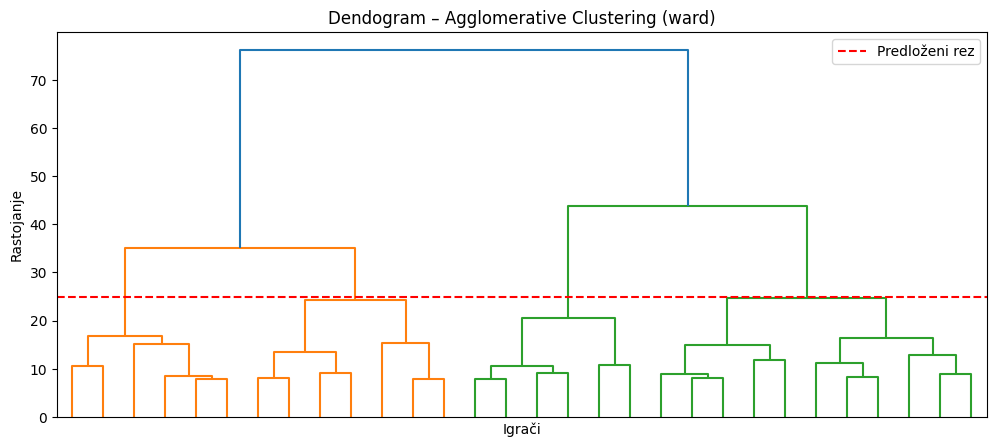

In [6]:
# Dendogram za određivanje broja klastera

from scipy.cluster.hierarchy import linkage

# Kreiranje matrice povezivanja za hijerarhijsko (agglomerative) klasterovanje.
linkage_matrix = linkage(X_scaled, method='ward')

# Kreiranje figure za prikaz dendograma
plt.figure(figsize=(12, 5))

# Prikaz dendograma.
# truncate_mode='lastp' prikazuje samo poslednjih p spajanja kako bi grafikon bio pregledniji.
# p=30 ograničava prikaz na poslednjih 30 formiranih grupa.
# no_labels=True uklanja oznake pojedinačnih igrača zbog preglednosti.
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    no_labels=True
)

# Dodavanje horizontalne linije koja predstavlja predloženi prag za formiranje klastera.
# Sečenjem dendograma na ovoj visini dobijamo određeni broj klastera.
plt.axhline(
    y=25,
    color='red',
    linestyle='--',
    label='Predloženi rez'
)

# Oznaka x ose – predstavljaju igrače odnosno formirane grupe igrača
plt.xlabel('Igrači')

# Oznaka y ose – predstavlja udaljenost pri spajanju klastera
plt.ylabel('Rastojanje')

# Naslov grafikona
plt.title('Dendogram – Agglomerative Clustering (ward)')

# Prikaz legende za označenu liniju preseka
plt.legend()

# Prikaz dendograma
plt.show()

In [7]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=3, linkage='ward')
ac_fitted_data = ac.fit(X_scaled)

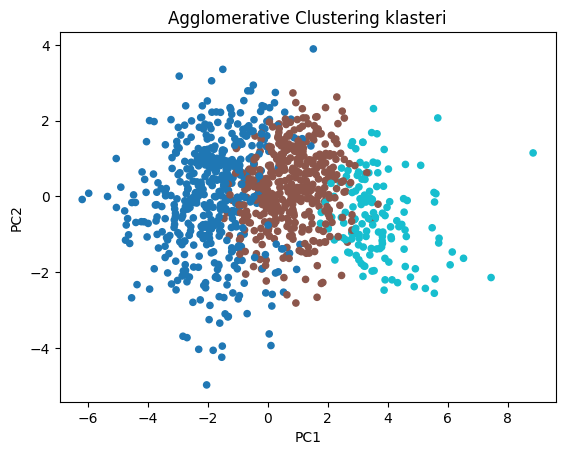

In [8]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=ac.labels_, cmap='tab10', s=20)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Agglomerative Clustering klasteri')
plt.show()


n_clusters=2: silhouette=0.2533
n_clusters=3: silhouette=0.1890
n_clusters=4: silhouette=0.1483
n_clusters=5: silhouette=0.1175
n_clusters=6: silhouette=0.1148
n_clusters=7: silhouette=0.1142
n_clusters=8: silhouette=0.0990
n_clusters=9: silhouette=0.0909


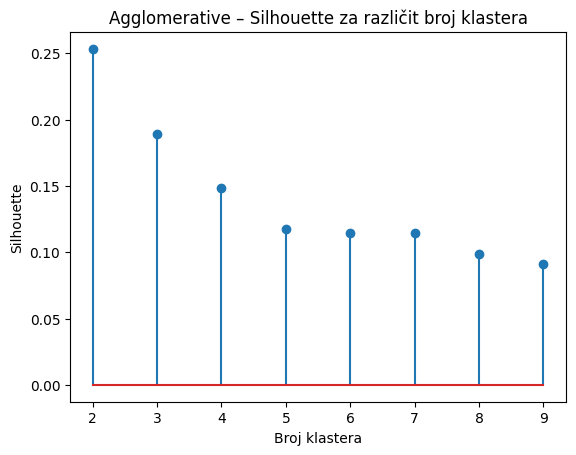

In [9]:
# Silhouette analiza za izbor broja klastera

silhouettes_ac = []

# Testiranje različitog broja klastera od 2 do 9
for n in range(2, 10):

    # Kreiranje modela aglomerativnog klasterovanja.
    ac_tmp = AgglomerativeClustering(
        n_clusters=n,
        linkage='ward'
    )

    # Primena klasterovanja i dobijanje oznaka klastera za svakog igrača.
    lbl = ac_tmp.fit_predict(X_scaled)

    # Izračunavanje silhouette koeficijenta.
    # Ova metrika meri koliko su objekti dobro grupisani:
    # vrednosti bliže 1 ukazuju na bolje razdvojene klastere,
    # vrednosti oko 0 na preklapanje klastera,
    # negativne vrednosti na lošu dodelu klastera.
    s = silhouette_score(X_scaled, lbl)

    # Čuvanje dobijene vrednosti za kasniji prikaz
    silhouettes_ac.append(s)

    # Ispis rezultata za trenutni broj klastera
    print(f"n_clusters={n}: silhouette={s:.4f}")


# Prikaz promene silhouette vrednosti u zavisnosti od broja klastera.
# Najviša vrednost ukazuje na najpogodniji broj klastera.
plt.stem(range(2, 10), silhouettes_ac)


plt.xlabel('Broj klastera')

plt.ylabel('Silhouette')

plt.title('Agglomerative – Silhouette za različit broj klastera')

plt.show()

In [10]:
best_k_ac = range(2, 10)[np.argmax(silhouettes_ac)]
print(f"Izabrani broj klastera: {best_k_ac}")

ac     = AgglomerativeClustering(n_clusters=best_k_ac, linkage='ward')
labels_ac = ac.fit_predict(X_scaled)

sil_ac = silhouette_score(X_scaled, labels_ac)
print(f"Silhouette koeficijent: {sil_ac:.4f}")

Izabrani broj klastera: 2
Silhouette koeficijent: 0.2533


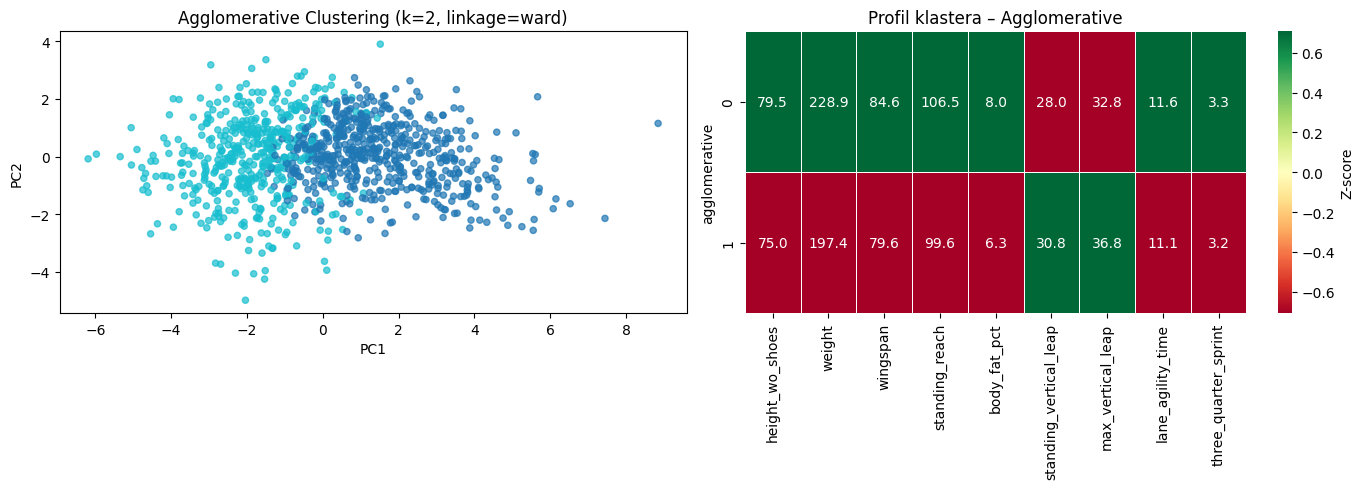

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

# Prikaz igrača u PCA prostoru.
# Boja tačke predstavlja pripadnost klasteru dobijenom Agglomerative metodom.
# cmap određuje paletu boja za različite klastere.
# s određuje veličinu tačaka, a alpha providnost.
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_ac,
    cmap='tab10',
    s=20,
    alpha=0.7
)

plt.title(f'Agglomerative Clustering (k={best_k_ac}, linkage=ward)')
plt.xlabel('PC1')
plt.ylabel('PC2')


# Drugi grafikon – analiza karakteristika dobijenih klastera
plt.subplot(1, 2, 2)
df_clean['agglomerative'] = labels_ac

# Računanje prosečnih vrednosti atributa za svaki klaster.
stats_ac = df_clean.groupby('agglomerative')[features].mean().round(1)


# Standardizacija prosečnih vrednosti atributa po klasterima.
# Z-score pokazuje koliko se vrednost svakog atributa razlikuje od proseka:
# pozitivne vrednosti označavaju iznadprosečne vrednosti,
# negativne ispodprosečne vrednosti.
sns.heatmap(
    (stats_ac - stats_ac.mean()) / stats_ac.std(),
    annot=stats_ac,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Z-score'}
)

plt.title('Profil klastera – Agglomerative')
plt.tight_layout()
plt.show()

In [12]:
pd.Series(labels_ac).value_counts()

0    560
1    456
Name: count, dtype: int64

## 2. GMM – Gaussian Mixture Model

Gaussian Mixture Model (GMM) pretpostavlja da su podaci generisani kao mešavina više Gausovih (normalnih) raspodela, pri čemu svaka raspodela predstavlja jedan klaster. Svaki klaster je opisan sopstvenim parametrima: srednjom vrednošću (centrom) i kovarijacionom matricom koja određuje oblik i rasprostranjenost klastera.

GMM predstavlja meko klasterovanje. To znači da se svakoj tački dodeljuje verovatnoća pripadnosti svakom od klastera, pa objekat može pripadati većem broju klastera.

Parametri modela (srednje vrednosti, kovarijanse i verovatnoće klastera) procenjuju se pomoću EM (Expectation-Maximization) algoritma, koji se iterativno izvršava kroz dva koraka: procenu verovatnoća pripadnosti tačaka klasterima (Expectation korak) i ažuriranje parametara modela (Maximization korak).

n_components=2: silhouette=0.2425
n_components=3: silhouette=0.1779
n_components=4: silhouette=0.1096
n_components=5: silhouette=0.0715
n_components=6: silhouette=0.0686
n_components=7: silhouette=0.0719
n_components=8: silhouette=0.0369
n_components=9: silhouette=0.0472


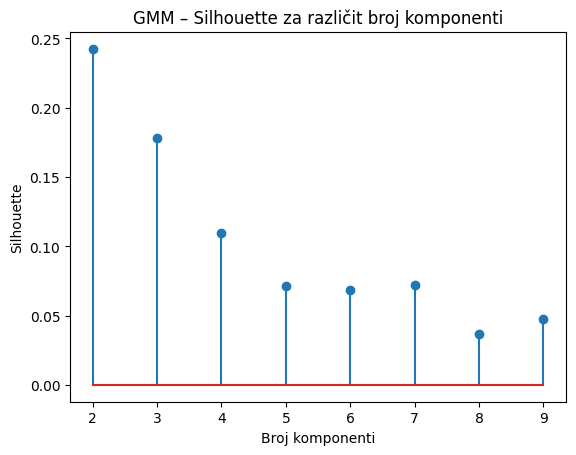

In [13]:
# Silhouette analiza za izbor broja komponenti
silhouettes_gmm = []

# Testiranje različitog broja komponenti u GMM modelu od 2 do 9
for n in range(2, 10):

    # Kreiranje Gaussian Mixture Model-a.
    # n_components predstavlja broj Gausovih raspodela, odnosno broj klastera.
    # random_state obezbeđuje ponovljivost rezultata pri svakom pokretanju.
    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )

    # Učenje parametara GMM modela pomoću EM algoritma.
    gmm.fit(X_scaled)

    # Dodela svakog igrača komponenti kojoj ima najveću verovatnoću pripadnosti.
    # Iako GMM predstavlja meko klasterovanje, za izračunavanje silhouette
    # koeficijenta koriste se konačne oznake klastera.
    lbl = gmm.predict(X_scaled)

    s = silhouette_score(X_scaled, lbl)
    silhouettes_gmm.append(s)
    print(f"n_components={n}: silhouette={s:.4f}")

plt.stem(range(2, 10), silhouettes_gmm)
plt.xlabel('Broj komponenti')
plt.ylabel('Silhouette')
plt.title('GMM – Silhouette za različit broj komponenti')
plt.show()


In [14]:
from sklearn.mixture import GaussianMixture

best_n_gmm = range(2, 10)[np.argmax(silhouettes_gmm)]
print(f"Izabrani broj komponenti: {best_n_gmm}")

gmm        = GaussianMixture(n_components=best_n_gmm, random_state=42)
gmm.fit(X_scaled)
labels_gmm = gmm.predict(X_scaled)


Izabrani broj komponenti: 2


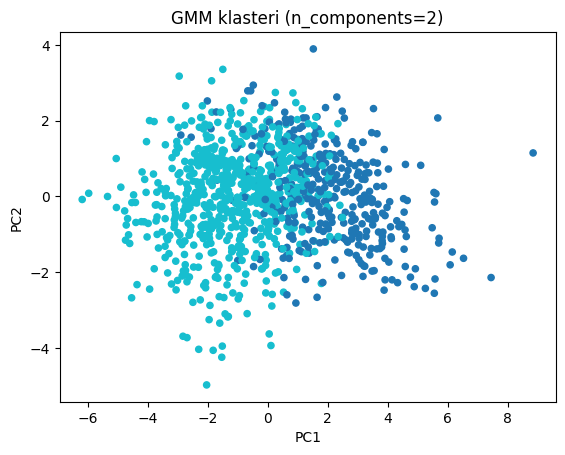

In [15]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap='tab10', s=20)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'GMM klasteri (n_components={best_n_gmm})')
plt.show()


In [16]:
sil_gmm = silhouette_score(X_scaled, labels_gmm)
print(f"Broj komponenti: {best_n_gmm}")
print(f"Silhouette koeficijent: {sil_gmm:.4f}")


Broj komponenti: 2
Silhouette koeficijent: 0.2425


In [17]:
# Verovatnoće pripadnosti – meko klasterovanje
proba    = gmm.predict_proba(X_scaled)
df_proba = pd.DataFrame(proba, columns=[f'K{i}' for i in range(best_n_gmm)])
df_proba['igrač']   = player_names
df_proba['klaster'] = labels_gmm
df_proba.head(10)


,K0,K1,igrač,klaster
0,0.999980,0.000020,Adam Allenspach,0
1,0.008976,0.991024,Gilbert Arenas,1
2,0.136994,0.863006,Brandon Armstrong,1
3,0.832524,0.167476,Shane Battier,0
4,0.036513,0.963487,Cookie Belcher,1
5,0.008287,0.991713,Charlie Bell,1
6,0.697601,0.302399,Ruben Boumtje-Boumtje,0
7,0.742571,0.257429,Calvin Bowman,0
8,0.775750,0.224250,Michael Bradley,0
9,0.048097,0.951903,Jamison Brewer,1


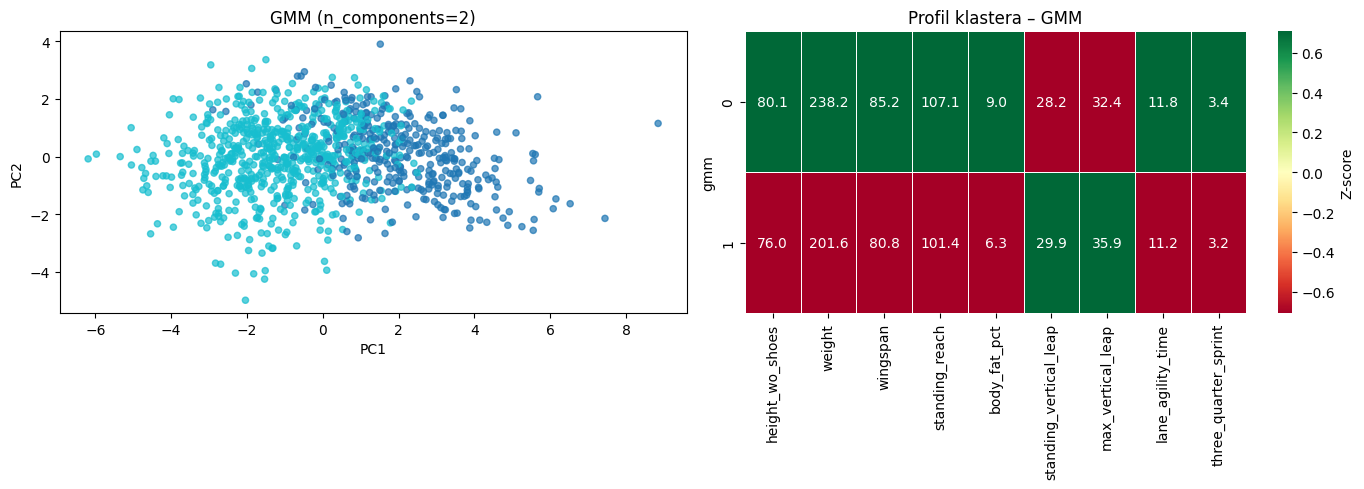

In [18]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap='tab10', s=20, alpha=0.7)
plt.title(f'GMM (n_components={best_n_gmm})')
plt.xlabel('PC1'); plt.ylabel('PC2')

plt.subplot(1, 2, 2)
df_clean['gmm'] = labels_gmm
stats_gmm = df_clean.groupby('gmm')[features].mean().round(1)
sns.heatmap((stats_gmm - stats_gmm.mean()) / stats_gmm.std(), annot=stats_gmm, fmt='.1f',
            cmap='RdYlGn', center=0, linewidths=0.5, cbar_kws={'label': 'Z-score'})
plt.title('Profil klastera – GMM')
plt.tight_layout()
plt.show()


In [19]:
pd.Series(labels_gmm).value_counts()


1    650
0    366
Name: count, dtype: int64

## 3. Spectral Clustering

Spectral Clustering zasniva se na predstavljanju podataka pomoću grafa sličnosti, gde čvorovi predstavljaju podatke, a težine grana određuju stepen njihove međusobne sličnosti. Nakon formiranja grafa, metoda koristi svojstvene vektore Laplasove matrice grafa kako bi podatke transformisala u novi prostor, u kome se zatim primenjuje klasično klasterovanje.

Ova metoda je posebno pogodna za pronalaženje klastera nepravilnih ili nelinearnih oblika, jer ne zahteva da klasteri budu sferni ili konveksni. Umesto toga, grupiše tačke koje su međusobno jako povezane, dok istovremeno razdvaja grupe koje imaju slabu povezanost.

Parametar affinity='rbf' određuje način računanja sličnosti između tačaka. U ovom slučaju koristi se Gausov (RBF – Radial Basis Function) kernel, koji dodeljuje veću sličnost tačkama koje su blizu jedna drugoj, dok se uticaj udaljenih tačaka smanjuje.

Ovakav pristup omogućava Spectral Clustering-u da pronađe strukture u podacima koje metode zasnovane samo na udaljenosti (npr. K-means) često ne mogu da detektuju.



n_clusters=2: silhouette=0.3127
n_clusters=3: silhouette=0.2395
n_clusters=4: silhouette=0.1810
n_clusters=5: silhouette=0.1401
n_clusters=6: silhouette=0.1110
n_clusters=7: silhouette=0.1005
n_clusters=8: silhouette=0.1026
n_clusters=9: silhouette=0.0916


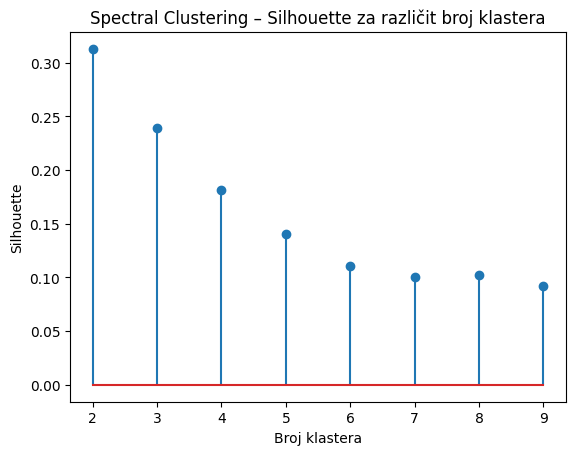

In [20]:
# Silhouette analiza za izbor k
silhouettes_sc = []
for n in range(2, 10):
    sc  = SpectralClustering(n_clusters=n, affinity='rbf', random_state=42)
    lbl = sc.fit_predict(X_scaled)
    s   = silhouette_score(X_scaled, lbl)
    silhouettes_sc.append(s)
    print(f"n_clusters={n}: silhouette={s:.4f}")

plt.stem(range(2, 10), silhouettes_sc)
plt.xlabel('Broj klastera')
plt.ylabel('Silhouette')
plt.title('Spectral Clustering – Silhouette za različit broj klastera')
plt.show()


In [21]:
from sklearn.cluster import SpectralClustering

best_k_sc = range(2, 10)[np.argmax(silhouettes_sc)]
print(f"Izabrani broj klastera: {best_k_sc}")

sc        = SpectralClustering(n_clusters=best_k_sc, affinity='rbf', random_state=42)
labels_sc = sc.fit_predict(X_scaled)


Izabrani broj klastera: 2


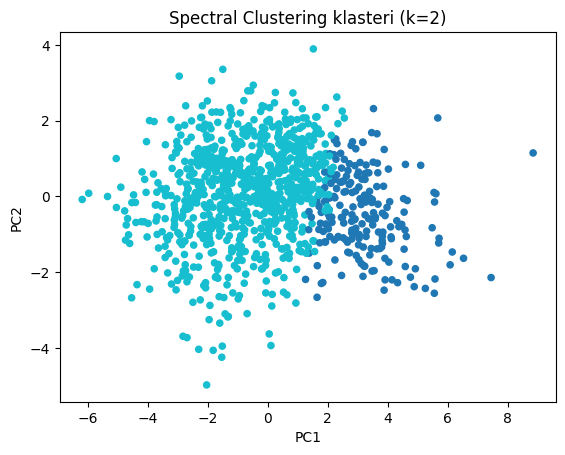

In [22]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_sc, cmap='tab10', s=20)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'Spectral Clustering klasteri (k={best_k_sc})')
plt.show()


In [23]:
sil_sc = silhouette_score(X_scaled, labels_sc)
print(f"Broj klastera: {best_k_sc}")
print(f"Silhouette koeficijent: {sil_sc:.4f}")


Broj klastera: 2
Silhouette koeficijent: 0.3127


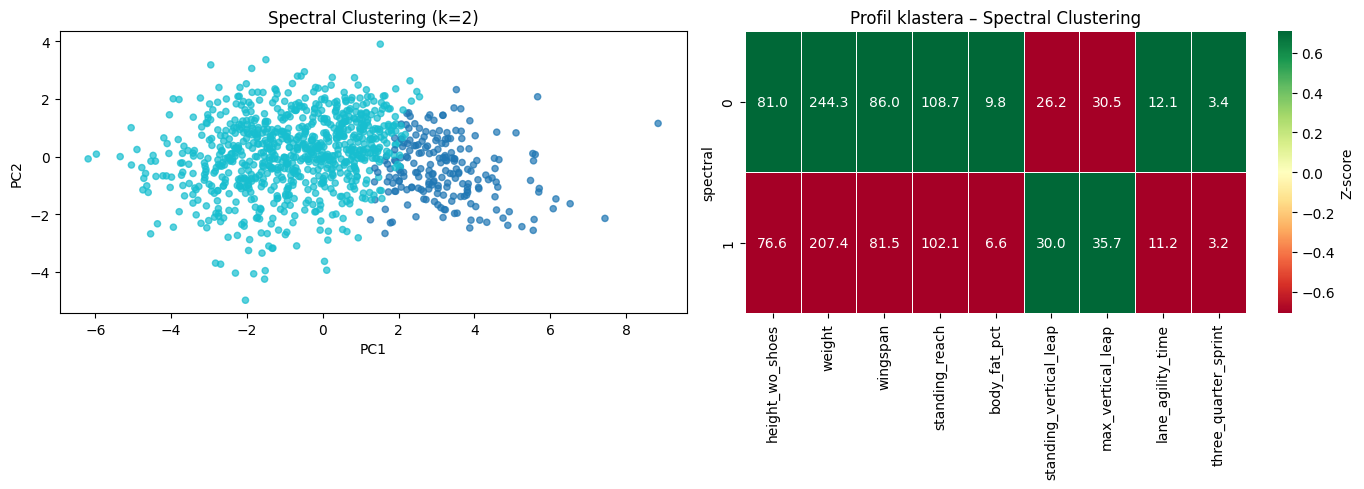

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_sc, cmap='tab10', s=20, alpha=0.7)
plt.title(f'Spectral Clustering (k={best_k_sc})')
plt.xlabel('PC1'); plt.ylabel('PC2')

plt.subplot(1, 2, 2)
df_clean['spectral'] = labels_sc
stats_sc = df_clean.groupby('spectral')[features].mean().round(1)
sns.heatmap((stats_sc - stats_sc.mean()) / stats_sc.std(), annot=stats_sc, fmt='.1f',
            cmap='RdYlGn', center=0, linewidths=0.5, cbar_kws={'label': 'Z-score'})
plt.title('Profil klastera – Spectral Clustering')
plt.tight_layout()
plt.show()


In [25]:
pd.Series(labels_sc).value_counts()


1    814
0    202
Name: count, dtype: int64

## 4. Poređenje algoritama

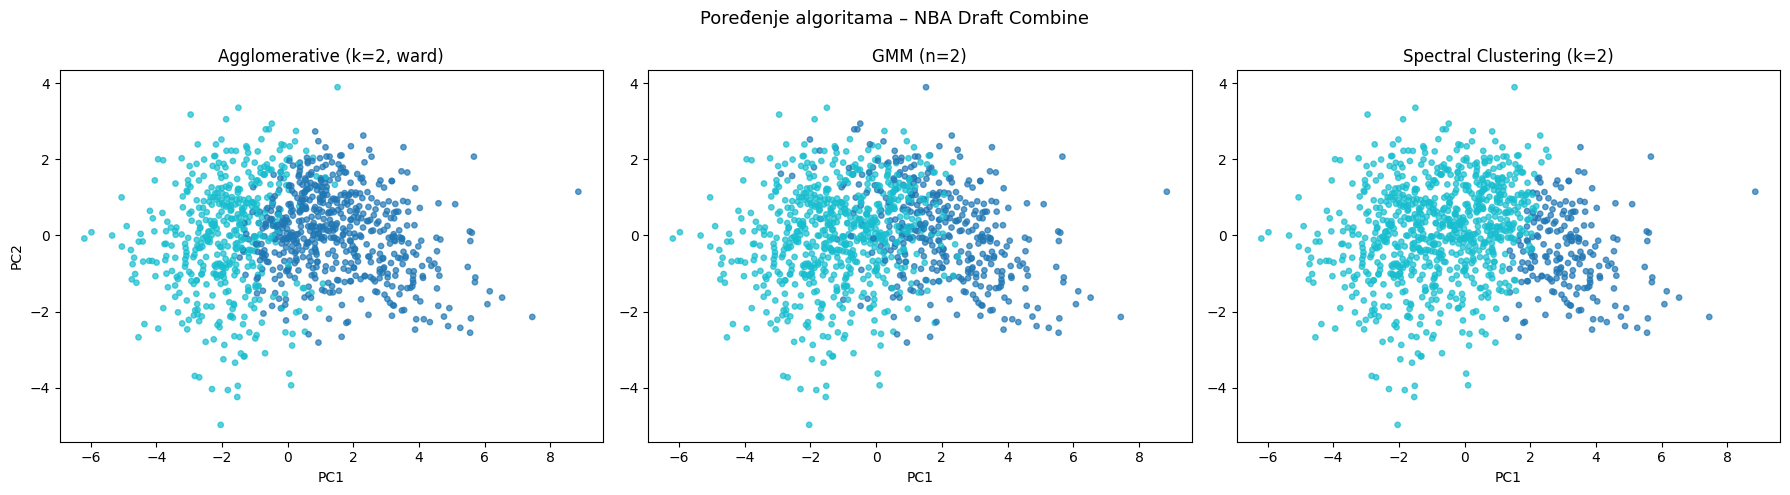

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_ac, cmap='tab10', s=15, alpha=0.7)
axes[0].set_title(f'Agglomerative (k={best_k_ac}, ward)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap='tab10', s=15, alpha=0.7)
axes[1].set_title(f'GMM (n={best_n_gmm})')
axes[1].set_xlabel('PC1')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_sc, cmap='tab10', s=15, alpha=0.7)
axes[2].set_title(f'Spectral Clustering (k={best_k_sc})')
axes[2].set_xlabel('PC1')

plt.suptitle('Poređenje algoritama – NBA Draft Combine', fontsize=13)
plt.tight_layout()
plt.show()


In [27]:
comparison = pd.DataFrame({
    'Algoritam':   ['Agglomerative', 'GMM', 'Spectral Clustering'],
    'Klastera':    [best_k_ac, best_n_gmm, best_k_sc],
    'Šum':         ['Ne', 'Ne', 'Ne'],
    'Silhouette':  [f"{sil_ac:.4f}", f"{sil_gmm:.4f}", f"{sil_sc:.4f}"],
    'Zadaje se k': ['Da', 'Da', 'Da'],
    'Tip':         ['Hijerarhijski', 'Statistički model', 'Graf sličnosti'],
})
display(comparison)


,Algoritam,Klastera,Šum,Silhouette,Zadaje se k,Tip
0,Agglomerative,2,Ne,0.2533,Da,Hijerarhijski
1,GMM,2,Ne,0.2425,Da,Statistički model
2,Spectral Clustering,2,Ne,0.3127,Da,Graf sličnosti


In [28]:
from joblib import dump, load

In [29]:
dump(ac, 'agg.joblib')
dump(gmm,'gmm.joblib')
dump(sc,'sc.joblib')

['sc.joblib']

## 5. K-Means Clustering

K-Means je algoritam klasterovanja baziran na centroidima – gradi klastere tako što iterativno:
1. Postavlja k centroida (reprezentanta klastera) slučajno
2. Za svaku tačku pronalazi najbliži centroid i dodeluje je tom klasteru
3. Pomera centroide na prosečnu poziciju tačaka u svakom klasteru
4. Ponavalja dok se centroidi ne stabilizuju

K-Means pretpostavlja da su klasteri sferni (kružnog oblika) i otprilike iste veličine. 
Iako je jednostavan, često daje dobre rezultate na heterogenim podacima.


Prednost K-Means-a je brzina i jednostavnost. Nedostatak je što ne pronalazi nekonveksne klastere kao Spectral Clustering, pa je Silhouette nešto manji od spektralnog pristupa.

In [30]:
from sklearn.cluster import HDBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import BisectingKMeans
from sklearn.cluster import DBSCAN

In [31]:

silhouettes_km = []

# Testiranje različitog broja klastera od 2 do 9
for n in range(2, 10):

    km = KMeans(
        n_clusters=n,
        random_state=42
    )

    # Primena K-Means algoritma nad standardizovanim podacima.
    # fit_predict() istovremeno trenira model i dodeljuje
    # svakom objektu oznaku klastera.
    labels_km = km.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels_km)
    silhouettes_km.append(s)


# Pronalaženje broja klastera koji daje najveći silhouette koeficijent
best_k_km = range(2, 10)[np.argmax(silhouettes_km)]

# Kreiranje konačnog K-Means modela sa optimalnim brojem klastera.
km = KMeans(
    n_clusters=best_k_km,
    random_state=42
)

# Treniranje modela i dodela oznaka klastera.
labels_km = km.fit_predict(X_scaled)
sil_km = silhouette_score(X_scaled, labels_km)

# Ispis 
print(f"K-Means: k={best_k_km}, silhouette={sil_km:.4f}")

K-Means: k=2, silhouette=0.2971


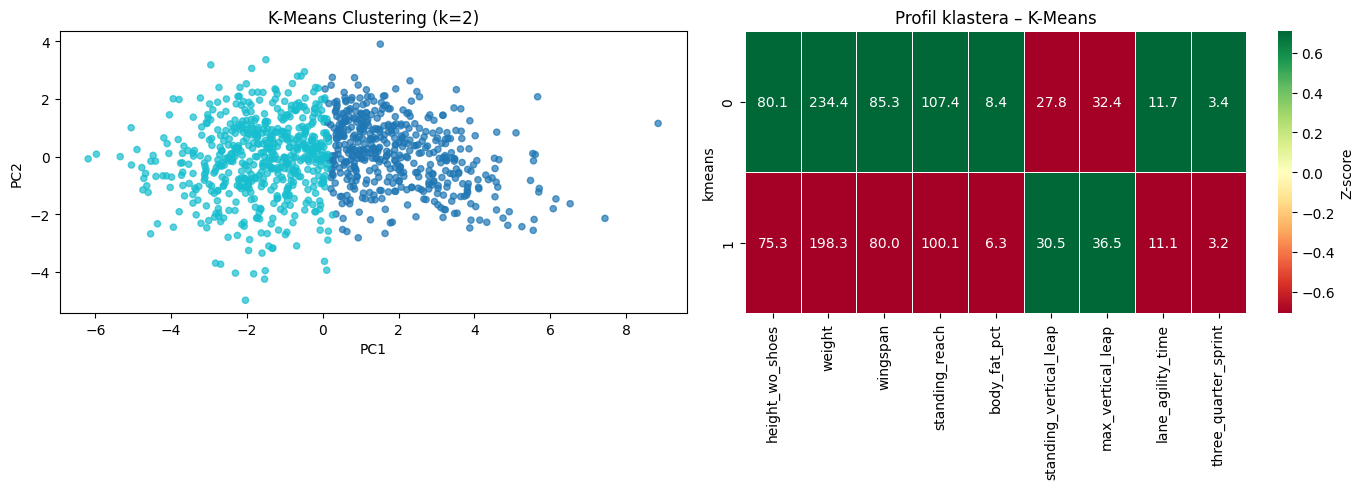

1    553
0    463
Name: count, dtype: int64

In [32]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

# Prikaz igrača u PCA prostoru.

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_km,
    cmap='tab10',
    s=20,
    alpha=0.7
)
plt.title(f'K-Means Clustering (k={best_k_km})')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Drugi grafikon – analiza karakteristika dobijenih klastera
plt.subplot(1, 2, 2)
df_clean['kmeans'] = labels_km
# Računanje prosečnih vrednosti atributa za svaki klaster.
stats_km = df_clean.groupby('kmeans')[features].mean().round(1)

# Standardizacija prosečnih vrednosti atributa po klasterima.
# Z-score pokazuje koliko se vrednost svakog atributa razlikuje od proseka:
# pozitivne vrednosti označavaju iznadprosečne vrednosti,
# negativne ispodprosečne vrednosti.
sns.heatmap(
    (stats_km - stats_km.mean(axis=0)) / stats_km.std(axis=0),
    annot=stats_km,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Z-score'}
)
plt.title('Profil klastera – K-Means')
plt.tight_layout()
plt.show()

pd.Series(labels_km).value_counts()

## 6. Bisecting K-Means Clustering

Bisecting K-Means je hijerarhijska verzija K-Means algoritma koja koristi **top-down pristup** 
(deljenje od vrha) za razliku od Agglomerative Clustering-a koji koristi bottom-up pristup 
(spajanje od dna).

### Princip

Algoritam funkcioniše iterativno:
1. Počinje sa svim tačkama u jednom klasteru
2. Pronalazi klaster sa najvećom disperzijom (razlikom)
3. Deli taj klaster na dva dela koristeći K-Means sa k=2
4. Ponavalja sve dok se ne postigne željeni broj klastera

Rezultat je stablo hijerarhije (kao dendrogram kod Agglomerative-a), ali konstruisano 
od vrha prema dnu umesto od dna prema vrhu.


In [33]:

silhouettes_bk = []


for n in range(2, 10):
    
    
    bk = BisectingKMeans(n_clusters=n, random_state=42)
    
    labels_bk = bk.fit_predict(X_scaled)
    
    
    s = silhouette_score(X_scaled, labels_bk)
    
    
    silhouettes_bk.append(s)

best_k_bk = range(2, 10)[np.argmax(silhouettes_bk)]

# Kreiraj FINALNI model sa najbolje pronađenim brojem klastera
bk = BisectingKMeans(n_clusters=best_k_bk, random_state=42)

# Trenira finalni model i dobija labele
# labels_bk je sada FINALNA podela igrača u best_k_bk klastera
labels_bk = bk.fit_predict(X_scaled)

# Izračunaj Silhouette za finalni model
sil_bk = silhouette_score(X_scaled, labels_bk)

# Ispis rezultata
# Vidim: koji k je najbolji i kolika je njegova Silhouette vrednost
print(f"Bisecting K-Means: k={best_k_bk}, silhouette={sil_bk:.4f}")

Bisecting K-Means: k=2, silhouette=0.2974


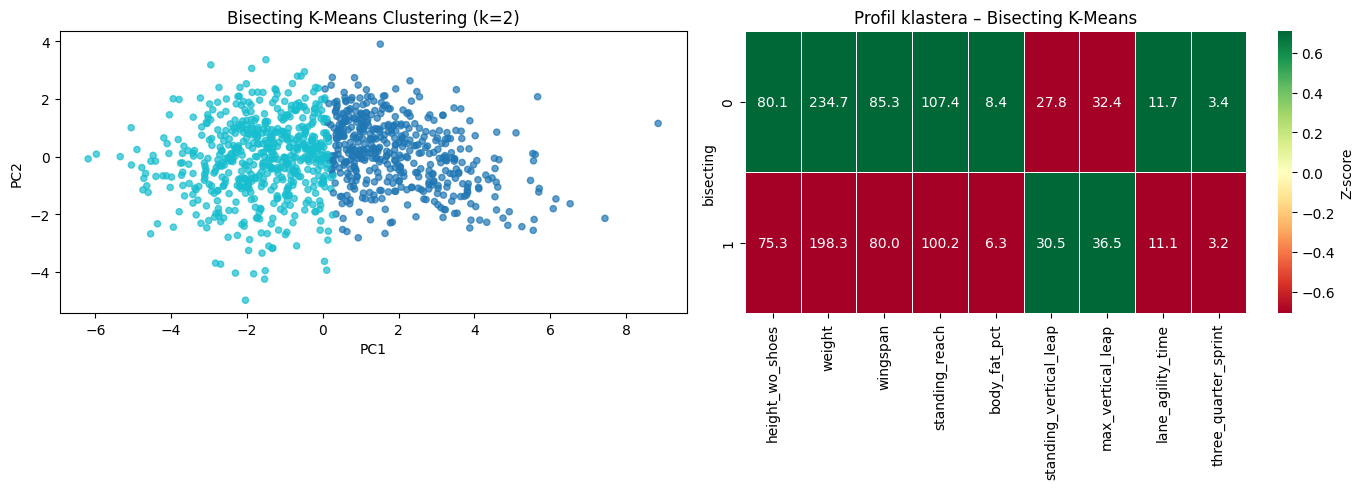

1    557
0    459
Name: count, dtype: int64

In [34]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Prikaz igrača u PCA prostoru.
# Boja tačke predstavlja pripadnost klasteru dobijenom Bisecting K-Means metodom.
# cmap određuje paletu boja za različite klastere.
# s određuje veličinu tačaka, a alpha providnost.
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_bk,
    cmap='tab10',
    s=20,
    alpha=0.7
)
plt.title(f'Bisecting K-Means Clustering (k={best_k_bk})')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Drugi grafikon – analiza karakteristika dobijenih klastera
plt.subplot(1, 2, 2)
df_clean['bisecting'] = labels_bk
# Računanje prosečnih vrednosti atributa za svaki klaster.
stats_bk = df_clean.groupby('bisecting')[features].mean().round(1)

sns.heatmap(
    (stats_bk - stats_bk.mean(axis=0)) / stats_bk.std(axis=0),
    annot=stats_bk,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Z-score'}
)
plt.title('Profil klastera – Bisecting K-Means')
plt.tight_layout()
plt.show()

pd.Series(labels_bk).value_counts()

## 7 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN je algoritam klasterovanja zasnovan na **gustini** - pronalazi grupe tačaka 
koje su međusobno gusto povezane i **razdvaja ih** od dalekih tačaka. Za razliku od 
prethodnih algoritama, DBSCAN **automatski pronalazi broj klastera** i može da 
identifikuje **šum** (outliers).

### Princip

DBSCAN pronalazi klastere sledećim principom:
1. Za svaku tačku, pronalazi sve tačke u radijusu `eps` 
2. Ako ima najmanje `min_samples` tačaka u tom radijusu, formira se klaster
3. Tačke u klasteru se povezuju i grade vece klastere
4. Tačke koje nisu deo nijednog klastera se oznčavaju kao **šum** (label = -1)

DBSCAN je posebno dobar za pronalaženje klastera nepravilnog oblika - može otkriti 
polumesece, prstene i druge kompleksne strukture koje algoritmi kao K-Means ne mogu.

### Izbor parametara

Dva ključna parametra:
- **eps**: Radijus претраге oko svake tačke
- **min_samples**: Minimalan broj tačaka potreban da se formira klaster

Izbor `eps` je bitan - premali eps  sve tačke su šum, prevelik eps - sve u jednom klasteru.





In [35]:
from sklearn.cluster import DBSCAN

print("DBSCAN - Pronalaženje optimalnog eps:\n")


best_result = None

# Petlja kroz različite eps vrednosti (0.5, 0.7, ..., 2.9)
for eps in np.arange(0.5, 3.0, 0.2):
    # Kreiraj DBSCAN model sa trenutnim eps
    # min_samples=5 znači "treba mi najmanje 5 tačaka u okolini da bi bile klasteri"
    db = DBSCAN(eps=eps, min_samples=5)
    
    # Primeni DBSCAN na standardizovane podatke
    # labels je niz od 1016 brojeva:
    # 0, 1, 2, ... = redni broj klastera
    # -1 = šum (outlier, ne pripada nijednom klasteru)
    labels = db.fit_predict(X_scaled)
    
    # Broji koliko je pronađeno klastera
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Broji koliko je pronađeno šuma
    n_noise = np.sum(labels == -1)
    
    # Kreiraj boolean masku za klasifikovane tačke (bez šuma)
    mask = labels != -1
    
    # Izračunaj Silhouette SAMO ako ima barem 2 klastera
    if n_clusters >= 2 and mask.sum() > 0:
        s = silhouette_score(X_scaled[mask], labels[mask])
        status = f"silhouette={s:.4f}"
        
        # Ako je ovo prvi validan rezultat ILI bolje nego do sada
        if best_result is None or s > best_result[1]:
            best_result = (eps, s, labels, n_clusters, n_noise)
    else:
        status = "N/A"
    
    # Ispis rezultata za ovaj eps
    print(f"eps={eps:.1f}: klastera={n_clusters}, šum={n_noise}, {status}")

# Provera: da li je pronađen validan rezultat?
if best_result:
    # Raspakuj tuple u pet promenljivih
    eps, sil, labels_db, n_db, noise_db = best_result
    
    
    print(f"\nNajbolji: eps={eps:.1f}, klastera={n_db}, šum={noise_db}, silhouette={sil:.4f}\n")
    
   
    
    # Prebroji igrače po klasterima
    cluster_counts = pd.Series(labels_db).value_counts().sort_index()
    
    print("Distribucija igrača po klasterima:")
    print("-" * 40)
    
    for cluster, count in cluster_counts.items():
        percentage = 100 * count / len(labels_db)
        
        if cluster == -1:
            # Šum
            print(f"Šum:       {count:4d} igrača ({percentage:5.1f}%)")
        else:
            # Obični klaster
            print(f"Klaster {cluster}: {count:4d} igrača ({percentage:5.1f}%)")
    
    print("-" * 40)
    print(f"Ukupno:    {len(labels_db):4d} igrača")
    
else:
    # Ako nijedan eps nije dao validne klastere
    print("\n✗ DBSCAN nije pronašao odgovarajuće klastere")

DBSCAN - Pronalaženje optimalnog eps:

eps=0.5: klastera=0, šum=1016, N/A
eps=0.7: klastera=0, šum=1016, N/A
eps=0.9: klastera=7, šum=944, silhouette=0.1762
eps=1.1: klastera=5, šum=596, silhouette=-0.1075
eps=1.3: klastera=1, šum=231, N/A
eps=1.5: klastera=1, šum=103, N/A
eps=1.7: klastera=1, šum=54, N/A
eps=1.9: klastera=1, šum=29, N/A
eps=2.1: klastera=1, šum=17, N/A
eps=2.3: klastera=1, šum=9, N/A
eps=2.5: klastera=1, šum=4, N/A
eps=2.7: klastera=1, šum=2, N/A
eps=2.9: klastera=1, šum=2, N/A

Najbolji: eps=0.9, klastera=7, šum=944, silhouette=0.1762

Distribucija igrača po klasterima:
----------------------------------------
Šum:        944 igrača ( 92.9%)
Klaster 0:   10 igrača (  1.0%)
Klaster 1:   28 igrača (  2.8%)
Klaster 2:    9 igrača (  0.9%)
Klaster 3:    5 igrača (  0.5%)
Klaster 4:   12 igrača (  1.2%)
Klaster 5:    4 igrača (  0.4%)
Klaster 6:    4 igrača (  0.4%)
----------------------------------------
Ukupno:    1016 igrača


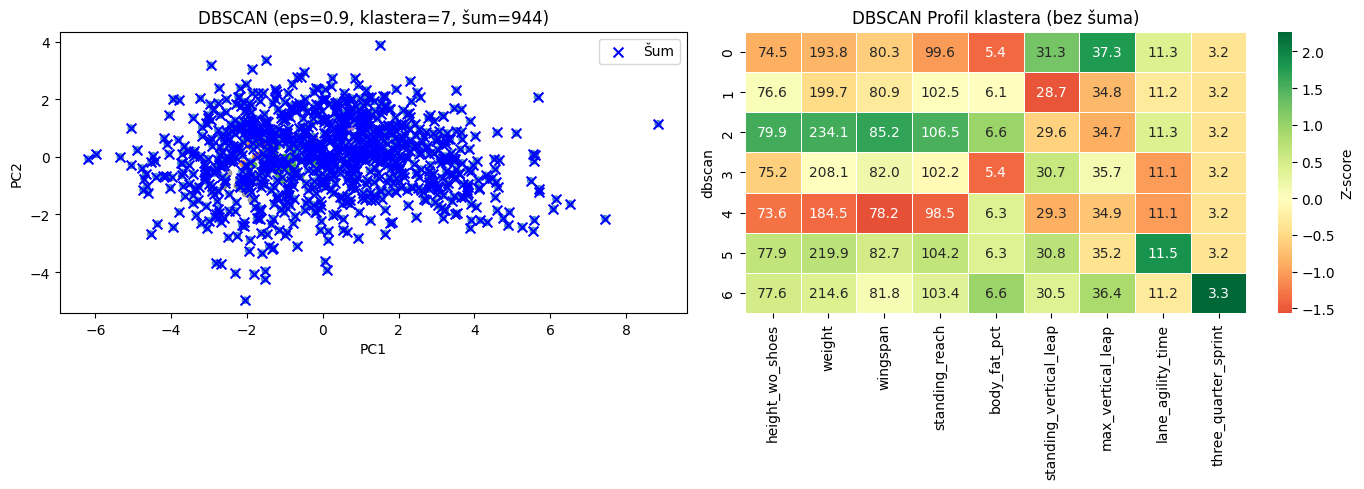

In [36]:
plt.figure(figsize=(14, 5))

# SCATTER PLOT
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap='tab10', s=20, alpha=0.7)
# Označi šum drugom bojom
noise_mask = labels_db == -1
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='blue', marker='x', s=50, label='Šum')
plt.title(f'DBSCAN (eps={eps:.1f}, klastera={n_db}, šum={noise_db})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

# HEATMAP PROFILA
plt.subplot(1, 2, 2)

# Dodaj DBSCAN labele u DataFrame
df_clean['dbscan'] = labels_db

# Izračunaj prosečne vrednosti SAMO za klasifikovane tačke (bez šuma)
# df_clean['dbscan'] != -1 → izdvoji samo redove gde nije šum
stats_db = df_clean[df_clean['dbscan'] != -1].groupby('dbscan')[features].mean().round(1)

# Nacrtaj heatmap
sns.heatmap(
    (stats_db - stats_db.mean(axis=0)) / stats_db.std(axis=0),
    annot=stats_db,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Z-score'}
)
plt.title('DBSCAN Profil klastera (bez šuma)')

plt.tight_layout()
plt.show()




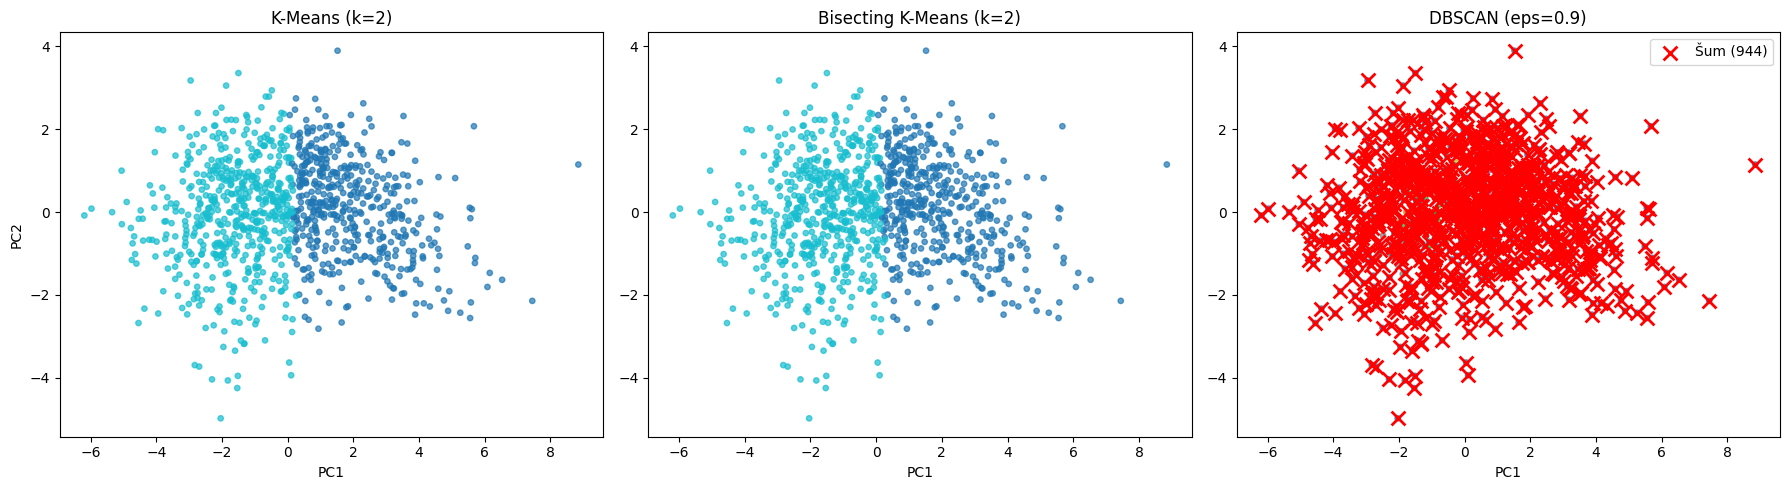

In [37]:
plt.figure(figsize=(18, 5))

# K-Means
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap='tab10', s=15, alpha=0.7)
plt.title(f'K-Means (k={best_k_km})')
plt.xlabel('PC1'); plt.ylabel('PC2')

# Bisecting K-Means
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_bk, cmap='tab10', s=15, alpha=0.7)
plt.title(f'Bisecting K-Means (k={best_k_bk})')
plt.xlabel('PC1')

# DBSCAN sa šumom
plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap='tab10', s=15, alpha=0.7)
noise_mask = labels_db == -1
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
           c='red', marker='x', s=100, linewidths=2, label=f'Šum ({noise_db})')
plt.title(f'DBSCAN (eps={eps:.1f})')
plt.xlabel('PC1')
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
dump(km, 'kmeans_marija.joblib')

# Novi - Bisecting K-Means
dump(bk, 'bisecting_marija.joblib')


db_final = DBSCAN(eps=eps, min_samples=5)
db_final.fit(X_scaled)
dump(db_final, 'dbscan_marija.joblib')

['dbscan_marija.joblib']